In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
import operator
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver



e:\learning AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


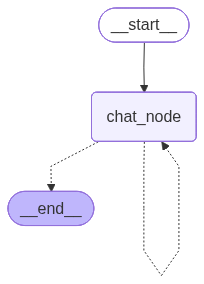

In [ ]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",  # Your Azure deployment name
    base_url="https://openai-rg-nadeem.openai.azure.com/openai/v1",
    #add your api key below
    api_key=
)

class State(TypedDict):
    human: str
    ai: str
    history: Annotated[list[BaseMessage], operator.add]

def chat_node(state: State):

    prompt = f"you have all the history as {state['history']} and you have to answer the question: {state['human']}"
    result = llm.invoke(prompt)
    answer = result.content
    state["history"] = state["history"] + HumanMessage(state['human'])
    return {
        "ai":answer,
        "history": state["history"] + AIMessage(answer)
    }

def routes(state: State):
    if state['human'] == "exit" or state['human'] == "bye":
        return "END"
    return "chat_node"

graph = StateGraph(State)
graph.add_node('chat_node', chat_node)
graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node',routes,
                            {
                                'chat_node': 'chat_node',
                                END: END
                            })


memory = MemorySaver()

workflow = graph.compile(
    checkpointer= memory
)

# print(workflow)

